<a href="https://colab.research.google.com/github/lauria02/my-colab-projects/blob/main/Skills_trending.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

How are in-demand skills trending for Data Analysts?

In [1]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
from google.colab import files
uploaded = files.upload()

Saving job_postings_flat.csv to job_postings_flat.csv


In [4]:
df = pd.read_csv('job_postings_flat.csv')

In [6]:
df['job_posted_date'] = pd.to_datetime(
    df['job_posted_date'],
    errors='coerce'
)

In [7]:
df['job_posted_date'].isna().sum()

np.int64(285845)

In [14]:
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

Group the Skills by Month

In [21]:
# Skill count per month for data analysts
df_DA_US = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'United States')].copy()

df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month

# Explode job_skills column
df_DA_US_explode = df_DA_US.explode('job_skills')

Pivot in Prep for Plotting

In [22]:
# Group by month and job_skills
df_DA_US_pivot = df_DA_US_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

df_DA_US_pivot

job_skills,airflow,airtable,alteryx,angular,ansible,arch,asp.net,assembly,atlassian,aurora,...,vba,visio,visual basic,vmware,windows,wire,word,workzone,xamarin,zoom
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1.0,2,0,16,0,0,0,0,0,0,1,...,7,2,3,0,2,0,28,0,0,1
2.0,4,0,5,0,0,1,0,0,1,2,...,6,0,3,0,3,0,21,0,0,0
3.0,3,1,8,0,0,0,0,0,0,1,...,12,2,1,0,1,0,23,0,1,2
4.0,2,0,4,0,1,2,0,0,0,1,...,8,1,2,0,2,0,27,0,0,2
5.0,2,0,6,0,0,0,0,1,0,0,...,11,3,1,0,0,0,22,1,0,1
6.0,2,0,10,0,1,0,1,0,0,1,...,9,2,2,0,1,0,21,0,0,0
7.0,5,0,8,2,0,0,0,0,0,0,...,10,3,2,0,0,0,14,0,0,0
8.0,4,0,6,1,0,1,0,0,0,0,...,6,3,0,0,1,0,22,0,0,3
9.0,5,0,13,0,0,1,1,0,0,1,...,8,2,3,0,0,1,30,0,0,1


Sort columns by count and change month numbers to names

In [23]:
# sorts by count
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()
df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_US_pivot = df_DA_US_pivot.drop('Total')

df_DA_US_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,word,powerpoint,sql server,...,puppet,powerbi,ruby on rails,seaborn,trello,vb.net,unreal,vmware,workzone,xamarin
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1.0,136,91,92,77,62,43,38,28,16,19,...,0,0,0,0,0,0,0,0,0,0
2.0,144,78,84,71,55,49,36,21,21,19,...,0,0,1,1,0,0,0,0,0,0
3.0,134,99,84,85,74,51,54,23,23,18,...,0,0,0,0,0,0,0,0,0,1
4.0,111,94,70,64,57,33,32,27,22,11,...,0,0,0,0,0,0,0,0,0,0
5.0,106,79,67,62,46,41,30,22,18,9,...,0,0,0,0,0,0,0,0,1,0
6.0,140,90,80,87,68,38,48,21,18,23,...,1,1,0,0,0,0,0,0,0,0
7.0,105,68,79,66,48,41,34,14,11,11,...,0,0,0,0,0,0,0,0,0,0
8.0,121,85,81,79,56,42,32,22,13,14,...,0,0,0,0,0,1,0,0,0,0
9.0,167,100,112,96,57,51,44,30,22,32,...,0,0,0,0,0,0,0,0,0,0


Plot the Monthly Skill Counts

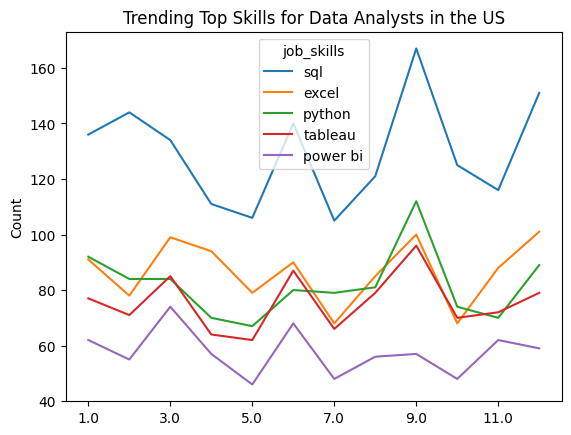

In [18]:
df_DA_US_pivot.iloc[:, :5].plot(kind='line')

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

Calculate Percentage of Total Jobs


In [19]:
# Get monthly totals
DA_totals = df_DA_US.groupby('job_posted_month_no').size()

DA_totals

,0
job_posted_month_no,
1.0,213
2.0,224
3.0,242
4.0,209
5.0,203
6.0,239
7.0,183
8.0,211
9.0,288


In [20]:
# divide first 12 rows of df_DA_pivot by DA_totals
df_DA_US_percent = df_DA_US_pivot.iloc[:12].div(DA_totals/100, axis=0)

# changes month number to month name
df_DA_US_percent = df_DA_US_percent.reset_index()
df_DA_US_percent['job_posted_month'] = df_DA_US_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_US_percent = df_DA_US_percent.set_index('job_posted_month')
df_DA_US_percent = df_DA_US_percent.drop(columns='job_posted_month_no')

df_DA_US_percent

job_skills,sql,excel,python,tableau,power bi,r,sas,word,powerpoint,sql server,...,puppet,powerbi,ruby on rails,seaborn,trello,vb.net,unreal,vmware,workzone,xamarin
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,63.849765,42.723005,43.192488,36.150235,29.107981,20.187793,17.840376,13.145540,7.511737,8.920188,...,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,64.285714,34.821429,37.500000,31.696429,24.553571,21.875000,16.071429,9.375000,9.375000,8.482143,...,0.00000,0.00000,0.446429,0.446429,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,55.371901,40.909091,34.710744,35.123967,30.578512,21.074380,22.314050,9.504132,9.504132,7.438017,...,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.413223
Apr,53.110048,44.976077,33.492823,30.622010,27.272727,15.789474,15.311005,12.918660,10.526316,5.263158,...,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
May,52.216749,38.916256,33.004926,30.541872,22.660099,20.197044,14.778325,10.837438,8.866995,4.433498,...,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.492611,0.000000
Jun,58.577406,37.656904,33.472803,36.401674,28.451883,15.899582,20.083682,8.786611,7.531381,9.623431,...,0.41841,0.41841,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Jul,57.377049,37.158470,43.169399,36.065574,26.229508,22.404372,18.579235,7.650273,6.010929,6.010929,...,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,57.345972,40.284360,38.388626,37.440758,26.540284,19.905213,15.165877,10.426540,6.161137,6.635071,...,0.00000,0.00000,0.000000,0.000000,0.00000,0.473934,0.000000,0.000000,0.000000,0.000000
Sep,57.986111,34.722222,38.888889,33.333333,19.791667,17.708333,15.277778,10.416667,7.638889,11.111111,...,0.00000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000


Plot Monthly Skill Demand

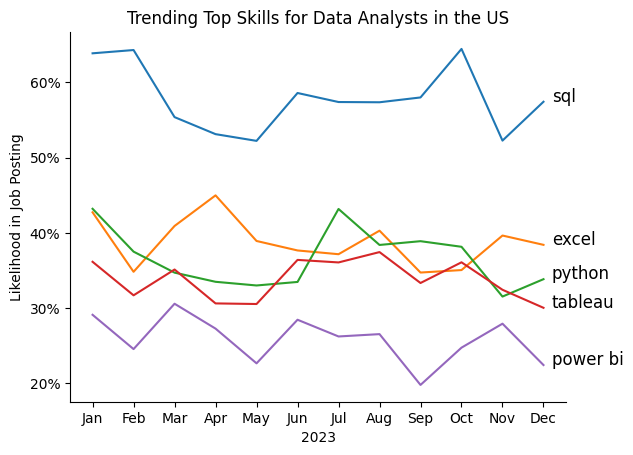

In [24]:
from matplotlib.ticker import PercentFormatter

df_plot = df_DA_US_percent.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine() # remove top and right spines

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

# annotate the plot with the top 5 skills using plt.text()
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], color='black')

plt.show()